## <center> Projeto Final — Pêndulo Simples (SME0104 - ICMC/USP) </center>
-----------------------------------------------------------
####  <center> Resolução do Problema de Valor de Contorno (PVC) não-linear via Método de Diferenças Finitas Centradas + Newton-Raphson. </center>

___________________________________________________________________



In [ ]:
# importando as bibliotecas e definindo constantes importantes: 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


T       = 2 * np.pi   # Período de análise [s]
L       = 1.0         # Comprimento do pêndulo [m]
g_terra = 9.8         # Aceleração gravitacional — Terra [m/s²]
g_mer   = 3.7         # Aceleração gravitacional — Mercúrio [m/s²]
alpha   = 0.7         # Condição de contorno: θ(0) [rad]
beta    = 0.7         # Condição de contorno: θ(T) [rad]
TOL     = 1e-10       # Tolerância de convergência
MAXITER = 100         # Número máximo de iterações de Newton

Vamos definir o Sistema de Eq. Não Lineares do pêndulo simples aproximada pelo método das diferenças finitas computacional:

$$
G_i(\boldsymbol{\theta}) = \begin{cases} 
\frac{1}{h^2}(\alpha - 2\theta_1 + \theta_2) + \frac{g}{L} \sin(\theta_1), & i = 1, \\ 
\frac{1}{h^2}(\theta_{i-1} - 2\theta_i + \theta_{i+1}) + \frac{g}{L} \sin(\theta_i), & i = 2, \dots, m - 1, \\ 
\frac{1}{h^2}(\theta_{m-1} - 2\theta_m + \beta) + \frac{g}{L} \sin(\theta_m), & i = m, 
\end{cases}
$$

In [ ]:
def montar_residuo(theta, h, L, g, alpha, beta):
    """
    Calcula o vetor resíduo G(θ) ∈ R^m conforme a discretização
    de diferenças finitas centradas da equação do pêndulo.

    """
    m  = len(theta)
    h2 = h * h
    G  = np.empty(m)

    for i in range(m):

        if i == 0:
            theta_esq = alpha 
        else: 
            theta_esq = theta[i - 1]

        if i == m-1: 
            theta_dir = beta
        else:
            theta_dir = theta[i + 1]

        G[i] = theta_esq - 2.0 * theta[i] + theta_dir + h2 * (g / L) * np.sin(theta[i])
        
    return G

Agora, vamos montar a matriz jacobiana $J(\theta)$ para nossa EDO. Conforme vimos, ela é calculada analiticamente e é dada por:

$$
J(\boldsymbol{\theta}) = \begin{bmatrix}
d_1 & 1/h^2 & 0 & \dots & 0 \\
1/h^2 & d_2 & 1/h^2 & \dots & 0 \\
0 & 1/h^2 & d_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \ddots & 1/h^2 \\
0 & 0 & 0 & \dots & d_m
\end{bmatrix}
$$

sendo $ d_i = -\frac{2}{h^2} + \frac{g}{L} \cos(\theta_i) $ para cada $i = 1, 2,...,m$

In [ ]:
def montar_jacobiana(theta, h, L, g):
    """
    Monta a Jacobiana analítica J(θ) ∈ R^{m×m}.

    """
    m  = len(theta)
    h2 = h * h
    J  = np.zeros((m, m))

    for i in range(m):
        J[i, i] = -2.0 + h2 * (g / L) * np.cos(theta[i])
        if i > 0:
            J[i, i - 1] = 1.0
        if i < m - 1:
            J[i, i + 1] = 1.0
    return J


Conforme podemos perceber, $J(\theta)$ apresenta uma estrutura **tridiagonal**, e por isso, é possível resolver o sistema linear que montaremos pelo **Algorítimo de Thomas**. 

O método funciona em duas etapas principais: Primeiro, realizamos um passo de eliminação progressiva, onde os coeficientes das diagonais são modificados sequencialmente; em seguida, aplica-se substituição regressiva a partir do último termo para encontrar as incógnitas de forma direta. 

- Essa abordagem reduz drasticamente o custo computacional de $O(n^3)$ para $O(n)$.

In [ ]:
def resolver_tridiagonal(A, b):
    """
    Resolve A·x = b pelo Algoritmo de Thomas.

    A deve ser uma matriz tridiagonal quadrada. O método realiza uma
    eliminação progressiva seguida de substituição regressiva.
    """
    n = len(b)
    if A.shape != (n, n):
        raise ValueError("A deve ser quadrada e compatível com b")

    a = np.zeros(n)  # subdiagonal
    d = np.zeros(n)  # diagonal principal
    c = np.zeros(n)  # superdiagonal

    for i in range(n):
        d[i] = A[i, i]
        if i > 0:
            a[i] = A[i, i - 1]
        if i < n - 1:
            c[i] = A[i, i + 1]

    rhs = b.astype(float).copy()

    for i in range(1, n):
        if abs(d[i - 1]) < 1e-300:
            raise np.linalg.LinAlgError("pivô nulo no sistema tridiagonal")
        fator = a[i] / d[i - 1]
        d[i] = d[i] - fator * c[i - 1]
        rhs[i] = rhs[i] - fator * rhs[i - 1]

    if abs(d[-1]) < 1e-300:
        raise np.linalg.LinAlgError("pivô nulo no sistema tridiagonal")

    x = np.zeros(n)
    x[-1] = rhs[-1] / d[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (rhs[i] - c[i] * x[i + 1]) / d[i]

    return x

Com as funções auxiliares criadas, podemos finalmente montar o **Método de Newton-Raphson** para um sistema de equações não-lineares:

In [ ]:
def newton_raphson(theta0, h, L, g, alpha, beta, tol=TOL, maxiter=MAXITER):
    """
    Algoritmo:
        Passo 1 : Calcule G(θ^(k)) e J(θ^(k))
        Passo 2 : Se ||G(θ^(k))||_∞ < ε₁ → pare  (critério no resíduo)
        Passo 3 : Resolva J(θ^(k)) · s^(k) = -G(θ^(k))
        Passo 4 : θ^(k+1) = θ^(k) + s^(k)
        Passo 5 : Se ||s^(k)||_∞ / ||θ^(k+1)||_∞ < ε₂ → pare
        Passo 6 : k ← k + 1; volte ao Passo 1

    Retorna
    -------
    theta_k : solução convergida
    erros   : histórico do erro relativo ε_r por iteração
    n_iter  : número de iterações realizadas
    """
    theta_k = theta0.copy()
    erros   = []

    for k in range(maxiter):
        # Avaliamos G e J 
        G = montar_residuo(theta_k, h, L, g, alpha, beta)
        J = montar_jacobiana(theta_k, h, L, g)

        # Critério de parada no vetor resíduo usando norma infinita
        if np.linalg.norm(G, ord=np.inf) < tol:
            print(f"  Convergiu (resíduo) em {k} iterações")
            return theta_k, erros, k

        # resolvemos o sistema linear J · s = -G pelo Algorítimo de Thomas
        s = resolver_tridiagonal(J, -G)

        # atualizamos o vetor theta_K para a próx. iteração
        theta_k = theta_k + s

        # Aplicando o Critério de parada do erro relativo
        eps_r = np.linalg.norm(s, ord=np.inf) \
                / (np.linalg.norm(theta_k, ord=np.inf) + 1e-300)
        erros.append(eps_r)

        if eps_r < tol:
            print(f"  Convergiu em {k + 1} iterações  (ε_r = {eps_r:.2e})")
            return theta_k, erros, k + 1


    print(f"  AVISO: não convergiu em {maxiter} iterações"
          f"  (ε_r = {erros[-1]:.2e})")
    return theta_k, erros, maxiter

Como iremos testar dois métodos para o chute inicial $\theta^{0}$ vamos montar uma função que resolve esse PVC dependendo do chute inicial:

- <u>**Chute constante:**</u>    $\theta^{0} = (0.7,0.7,...,0.7)^T$ 

- <u>**Chute senoidal:**</u>     $\theta^{0} = (θ^0)_i = 0.7 − \sin(t_i/2)$

In [ ]:
def resolver_pvc(m, L, g, alpha, beta, chute="constante", label=""):
    """
    Resolve o PVC do pêndulo com m pontos internos.

    Parâmetros
    ----------
    m      : número de pontos internos da malha
    chute  : 'constante' → θ^(0) = (0.7, …, 0.7)
             'senoidal'  → (θ^(0))_i = 0.7 − sin(t_i / 2)

    Retorna (t_completo, theta_completo, erros)
    """
    h     = T / (m + 1)
    t_int = np.array([(i + 1) * h for i in range(m)])   # nós internos

    if chute == "constante":
        theta0 = np.full(m, 0.7)
    elif chute == "senoidal":
        theta0 = 0.7 - np.sin(t_int / 2)
    else:
        raise ValueError("chute deve ser 'constante' ou 'senoidal'")

    print(f"\n[[{label}]]  m = {m},  chute = {chute}")
    theta_sol, erros, n_iter = newton_raphson(theta0, h, L, g, alpha, beta)

    t_full     = np.concatenate([[0.0],  t_int,     [T]])
    theta_full = np.concatenate([[alpha], theta_sol, [beta]])

    return t_full, theta_full, erros

Partindo para a resolução do problema em si, vamos primeiramente testar a eficiência dos dois tipos de chute inicial $\theta^{0}$ para diferentes valores de resolução da malha: 

- $m = 100$
- $m = 1000$

In [ ]:
resultados = {}
for m in [100, 1000]:
    for chute in ["constante", "senoidal"]:
        t, theta, erros = resolver_pvc(m, L, g_terra, alpha, beta,
                                        chute=chute,
                                        label=f"m={m}, {chute}")
        resultados[(m, chute)] = (t, theta, erros)

# Graficando as soluções
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Pêndulo Simples — Solução θ(t) via Newton-Raphson", fontsize=14)

for idx, m in enumerate([100, 1000]):
    ax = axes[idx]
    for chute, ls in [("constante", "-"), ("senoidal", "--")]:
        t, theta, _ = resultados[(m, chute)]
        ax.plot(t, theta, ls, label=f"Chute {chute}")
    ax.set_title(f"m = {m} pontos internos")
    ax.set_xlabel("t  (s)")
    ax.set_ylabel("θ  (rad)")
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Agora plotando o erro relativo para ambos os chutes e valores de malha na escala de log:

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Convergência de Newton-Raphson — Erro Relativo ε_r", fontsize=14)

for idx, m in enumerate([100, 1000]):
    ax = axes[idx]
    for chute, ls, cor in [("constante", "o-", "tab:blue"),
                            ("senoidal",  "s--", "tab:orange")]:
        _, _, erros = resultados[(m, chute)]
        ax.semilogy(range(1, len(erros) + 1), erros,
                    ls, color=cor, label=f"Chute {chute}", markersize=5)
    ax.set_title(f"m = {m} pontos internos")
    ax.set_xlabel("Iteração k")
    ax.set_ylabel("ε_r  (escala log)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.4)

plt.tight_layout()
plt.show()

Como sabemos, ao trabalharmos o problema do pêndulo simples normalmente utiliza-se a linearização: $\sin(\theta) \approx \theta$ para que a EDO seja facilmente resolvida para $\theta < 15º$. Mas como será que essa solução linearizada se comporta frente a solução completa resolvida numericamente para diferentes ângulos?


In [ ]:
def resolver_pvc_linear(m, L, g, alpha, beta):
    """
    Resolve a versão linearizada (sin θ ≈ θ)
    """
    
    h     = T / (m + 1)
    t_int = np.array([(i + 1) * h for i in range(m)])
    h2    = h * h

    # Monta sistema tridiagonal linear:  A·θ = b
    A = np.zeros((m, m))
    b = np.zeros(m)
    for i in range(m):
        A[i, i] = -2.0 + h2 * (g / L)
        if i > 0:
            A[i, i - 1] = 1.0
        if i < m - 1:
            A[i, i + 1] = 1.0
        # termos das condições de contorno no vetor b
        if i == 0:
            b[i] = -alpha
        if i == m - 1:
            b[i] -= beta

    theta_lin = resolver_tridiagonal(A, b)

    t_full     = np.concatenate([[0.0],  t_int,     [T]])
    theta_full = np.concatenate([[alpha], theta_lin, [beta]])
    return t_full, theta_full


In [ ]:
m = 100
t_nl, theta_nl, _ = resolver_pvc(m, L, g_terra, alpha, beta,
                                    chute="senoidal", label="Não-linear")
t_lin, theta_lin = resolver_pvc_linear(m, L, g_terra, alpha, beta)

plt.figure(figsize=(8, 5))
plt.plot(t_nl,  theta_nl,  label="Não-linear  [sin(θ)]")
plt.plot(t_lin, theta_lin, "--", label="Linearizado  [sin(θ) ≈ θ]")
plt.title("Comparação: modelo não-linear vs linearizado  (m = 100, α = β = 0.7 rad)")
plt.xlabel("t  (s)")
plt.ylabel("θ  (rad)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Agora, vamos ver as diferenças no período de oscilação para um pêndulo na Terra e outro em Mercúrio:

- $g_{mer} \approx 3.7 m/s²$
- $g_{terra} \approx 9.8 m/s²$


[[Terra  (g = 9.8 m/s²)]]  m = 100,  chute = constante
  Convergiu (resíduo) em 8 iterações

[[Mercúrio  (g = 3.7 m/s²)]]  m = 100,  chute = constante
  Convergiu (resíduo) em 5 iterações


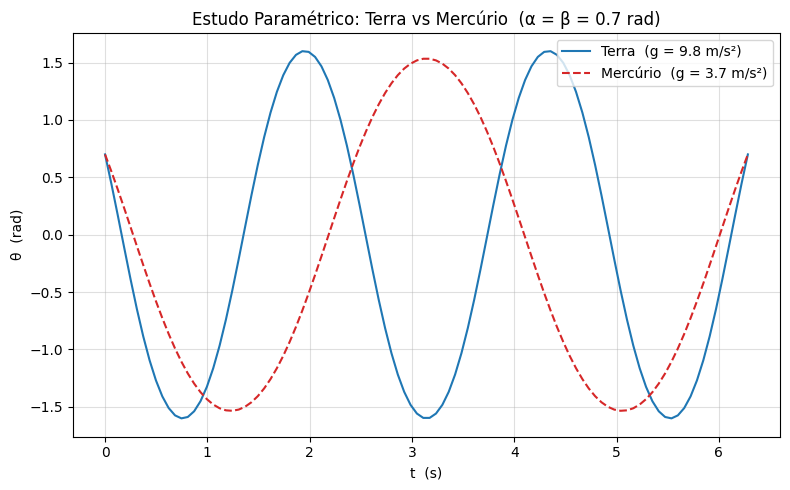

In [18]:
m = 100
plt.figure(figsize=(8, 5))
for grav, nome, ls, cor in [
    (g_terra, f"Terra  (g = {g_terra} m/s²)", "-",  "tab:blue"),
    (g_mer,   f"Mercúrio  (g = {g_mer} m/s²)", "--", "tab:red"),
]:
    t_p, th_p, _ = resolver_pvc(m, L, grav, alpha, beta,
                                chute="constante", label=nome)
    plt.plot(t_p, th_p, ls, color=cor, label=nome)

plt.title("Estudo Paramétrico: Terra vs Mercúrio  (α = β = 0.7 rad)")
plt.xlabel("t  (s)")
plt.ylabel("θ  (rad)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Enquanto faziamos o trabalho, percebemos uma sensabilidade muito grande de nosso sistema às condições de contorno. Se mudássemos os valores de $\alpha$ e $\beta$ **o sistema parava de convergir!**

Decidimos investigar a estrutura caótica do problema e as bacias de atração da EDO plotando um gráfico analisando se a convergência (ou não) do sistema em função de $\alpha$ e $\beta$:

In [22]:
def mapa_sensibilidade(m=100, n_alpha=60, n_beta=60):
    """
    Varre um grid de condições iniciais (alpha, beta) e registra
    o número de iterações de Newton necessário para convergir.
    Regiões de alta variação revelam estrutura fractal na bacia
    de atração do método.
    """
    alphas = np.linspace(0, 10, n_alpha)
    betas  = np.linspace(0, 10, n_beta)
    itermap = np.zeros((n_beta, n_alpha))

    for j, a in enumerate(alphas):
        for i, b_ in enumerate(betas):
            h      = T / (m + 1)
            theta0 = np.full(m, (a + b_) / 2)
            try:
                _, _, n = newton_raphson(theta0, h, L, g_terra, a, b_,
                                         tol=1e-10, maxiter=100)
                itermap[i, j] = n
            except np.linalg.LinAlgError:
                itermap[i, j] = 100  # singular → divergiu

    return alphas, betas, itermap


Gerando mapa de sensibilidade (fractais)... aguarde.
  Convergiu (resíduo) em 0 iterações
  Convergiu (resíduo) em 3 iterações
  Convergiu (resíduo) em 4 iterações
  Convergiu (resíduo) em 11 iterações
  AVISO: não convergiu em 100 iterações  (ε_r = 1.17e+00)
  AVISO: não convergiu em 100 iterações  (ε_r = 1.65e+00)
  AVISO: não convergiu em 100 iterações  (ε_r = 3.49e-01)
  AVISO: não convergiu em 100 iterações  (ε_r = 8.04e-01)
  AVISO: não convergiu em 100 iterações  (ε_r = 1.08e+00)
  Convergiu (resíduo) em 8 iterações
  AVISO: não convergiu em 100 iterações  (ε_r = 6.46e-01)
  Convergiu (resíduo) em 7 iterações
  Convergiu (resíduo) em 6 iterações
  Convergiu (resíduo) em 6 iterações
  Convergiu (resíduo) em 6 iterações
  AVISO: não convergiu em 100 iterações  (ε_r = 7.07e-01)
  AVISO: não convergiu em 100 iterações  (ε_r = 8.61e-01)
  AVISO: não convergiu em 100 iterações  (ε_r = 8.05e-01)
  AVISO: não convergiu em 100 iterações  (ε_r = 5.11e-01)
  AVISO: não convergiu em 100 it

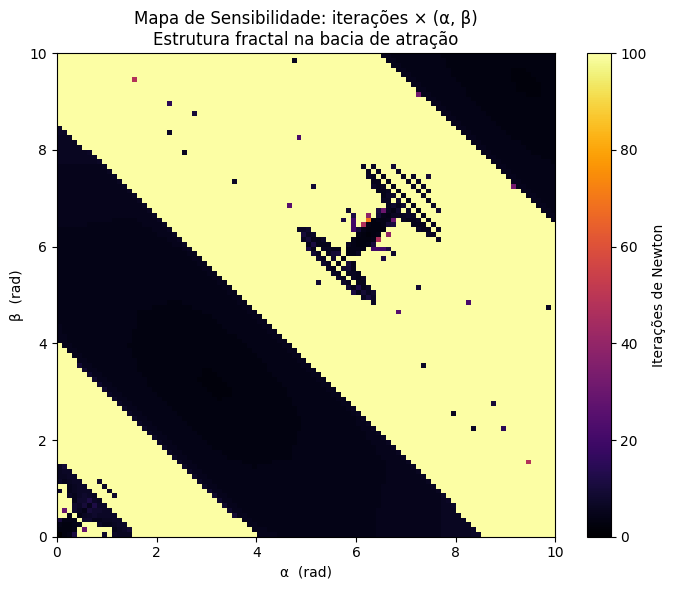

In [23]:
print("\nGerando mapa de sensibilidade (fractais)... aguarde.")

alphas, betas, itermap = mapa_sensibilidade(m=100, n_alpha=100, n_beta=100)

plt.figure(figsize=(7, 6))
plt.imshow(itermap, origin="lower", aspect="auto",
            extent=[alphas[0], alphas[-1], betas[0], betas[-1]],
            cmap="inferno")
cb = plt.colorbar()
cb.set_label("Iterações de Newton")
plt.title("Mapa de Sensibilidade: iterações × (α, β)\n"
            "Estrutura fractal na bacia de atração")
plt.xlabel("α  (rad)")
plt.ylabel("β  (rad)")
plt.tight_layout()